# Europe Retail Sales: Performance Story
**Role:** Retail data analyst  |  **Dataset:** [Europe Sales Records (Kaggle)](https://www.kaggle.com/datasets/mustafabayar/europe-sales-records)

**Business questions:** key trends, profit margin, best-selling products, seasonality, and promotional campaign impact.

In [2]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "axes.titlesize": 12})
M = mtick.FuncFormatter(lambda x, _: f"${x/1e6:,.1f}".rstrip("0").rstrip(".") + "M")
P = mtick.PercentFormatter(1.0, decimals=0)

df = pd.read_csv("Europe Sales Records.csv", parse_dates=["Order Date", "Ship Date"])
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Quarter"] = df["Order Date"].dt.quarter
df["Ship Days"] = (df["Ship Date"] - df["Order Date"]).dt.days
df.head(10)

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,Year,Month,Quarter,Ship Days
0,Europe,Czech Republic,Beverages,Offline,C,2011-09-12,478051030,2011-09-29,4778,47.45,31.79,226716.10,151892.62,74823.48,2011,9,3,17
1,Europe,Bosnia and Herzegovina,Clothes,Online,M,2013-10-14,919133651,2013-11-04,927,109.28,35.84,101302.56,33223.68,68078.88,2013,10,4,21
2,Europe,Austria,Cereal,Offline,C,2014-08-13,987410676,2014-09-06,5616,205.70,117.11,1155211.20,657689.76,497521.44,2014,8,3,24
3,Europe,Bulgaria,Office Supplies,Online,L,2010-10-31,672330081,2010-11-29,6266,651.21,524.96,4080481.86,3289399.36,791082.50,2010,10,4,29
4,Europe,Estonia,Fruits,Online,L,2016-09-28,579463422,2016-11-01,4958,9.33,6.92,46258.14,34309.36,11948.78,2016,9,3,34
5,Europe,Montenegro,Fruits,Offline,L,2016-05-29,313705861,2016-07-10,1390,9.33,6.92,12968.70,9618.80,3349.90,2016,5,2,42
6,Europe,Czech Republic,Cereal,Online,M,2011-07-08,552037513,2011-08-05,9022,205.70,117.11,1855825.40,1056566.42,799258.98,2011,7,3,28
7,Europe,Luxembourg,Vegetables,Offline,L,2010-02-13,744683635,2010-04-01,7291,154.06,90.93,1123251.46,662970.63,460280.83,2010,2,1,47
8,Europe,Switzerland,Meat,Online,L,2014-03-21,169378983,2014-04-10,1860,421.89,364.69,784715.40,678323.40,106392.00,2014,3,1,20
9,Europe,Finland,Beverages,Online,H,2012-03-16,566428315,2012-03-23,7581,47.45,31.79,359718.45,240999.99,118718.46,2012,3,1,7


## 1. Data check

In [2]:
print(f"Rows: {len(df):,} | Countries: {df['Country'].nunique()} | Products: {df['Item Type'].nunique()}")
print(f"Order dates: {df['Order Date'].min():%d %b %Y} to {df['Order Date'].max():%d %b %Y}")
print(f"Missing values: {int(df.isna().sum().sum())} | Duplicate order IDs: {int(df['Order ID'].duplicated().sum())}")
print(f"Rows where Revenue - Cost != Profit: {int(((df['Total Revenue']-df['Total Cost']-df['Total Profit']).abs()>1).sum())}")
print("Distinct unit prices per product (1 = fixed price all period):")
print(df.groupby("Item Type")["Unit Price"].nunique().value_counts().to_dict())

Rows: 1,330 | Countries: 48 | Products: 12
Order dates: 01 Jan 2010 to 23 Jul 2017
Missing values: 0 | Duplicate order IDs: 0
Rows where Revenue - Cost != Profit: 0
Distinct unit prices per product (1 = fixed price all period):
{1: 12}


**What this tells us**
- The data is clean: no missing values, no duplicate orders, and profit always equals revenue minus cost.
- 2017 only runs to July, so it's a **partial year**. I exclude it from year-over-year growth claims and from seasonality.
- Every product sells at **one fixed price and one fixed cost**. This matters for the promo question in section 6.

## 2. Headline KPIs

In [3]:
rev, cost, prof = df[["Total Revenue","Total Cost","Total Profit"]].sum()
kpi = pd.DataFrame({
    "Metric": ["Orders","Units sold","Revenue","Profit","Profit margin","Avg order value","Avg profit / order"],
    "Value": [f"{len(df):,}", f"{df['Units Sold'].sum():,}", f"${rev/1e9:.2f}B", f"${prof/1e6:,.0f}M",
              f"{prof/rev:.1%}", f"${rev/len(df)/1e6:.2f}M", f"${prof/len(df)/1e3:,.0f}K"]})
kpi

,Metric,Value
0,Orders,"1,330"
1,Units sold,"6,582,322"
2,Revenue,$1.70B
3,Profit,$502M
4,Profit margin,29.4%
5,Avg order value,$1.28M
6,Avg profit / order,$377K


## 3. Key trends over time

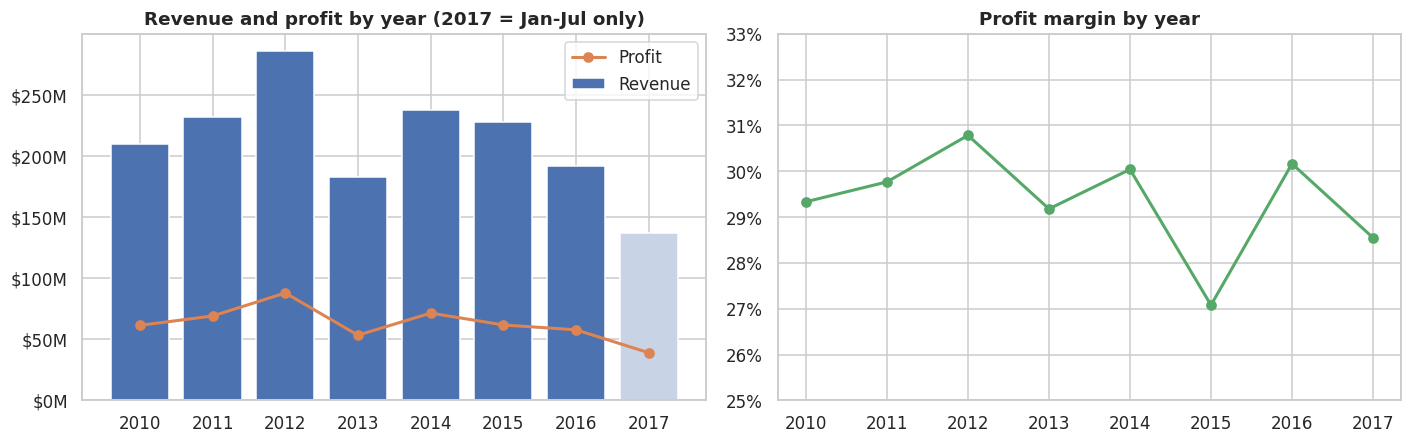

,Revenue,Profit,Units,Orders,Margin,Revenue growth
Year,,,,,,
2010,"$209,382,247","$61,422,460","843,713",166,29.3%,+nan%
2011,"$231,937,557","$69,044,660","906,147",175,29.8%,+10.8%
2012,"$285,485,892","$87,884,066","1,055,249",202,30.8%,+23.1%
2013,"$182,962,359","$53,387,995","770,550",158,29.2%,-35.9%
2014,"$237,778,813","$71,431,215","910,525",188,30.0%,+30.0%
2015,"$227,954,099","$61,734,040","758,689",160,27.1%,-4.1%
2016,"$191,520,957","$57,771,921","823,955",175,30.2%,-16.0%
2017,"$136,600,474","$38,999,691","513,494",106,28.6%,+nan%


In [4]:
yr = df.groupby("Year").agg(Revenue=("Total Revenue","sum"), Profit=("Total Profit","sum"),
                            Units=("Units Sold","sum"), Orders=("Order ID","count"))
yr["Margin"] = yr.Profit / yr.Revenue
yr["Revenue growth"] = yr.Revenue.pct_change()
yr.loc[2017, "Revenue growth"] = np.nan   # partial year

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
cols = ["#4C72B0"]*7 + ["#C9D3E6"]
ax[0].bar(yr.index, yr.Revenue, color=cols, label="Revenue")
ax[0].plot(yr.index, yr.Profit, color="#DD8452", marker="o", lw=2, label="Profit")
ax[0].yaxis.set_major_formatter(M); ax[0].set_title("Revenue and profit by year (2017 = Jan-Jul only)")
ax[0].legend()
ax[1].plot(yr.index, yr.Margin, marker="o", color="#55A868", lw=2)
ax[1].yaxis.set_major_formatter(P); ax[1].set_ylim(0.25, 0.33); ax[1].set_title("Profit margin by year")
plt.tight_layout(); plt.show()
yr.style.format({"Revenue":"${:,.0f}","Profit":"${:,.0f}","Units":"{:,.0f}","Margin":"{:.1%}","Revenue growth":"{:+.1%}"})

In [5]:
full = yr.loc[2010:2016]
peak = full.Revenue.idxmax(); low = full.Revenue.idxmin()
print(f"Peak full year: {peak} (${full.Revenue.max()/1e6:,.0f}M). Lowest full year: {low} (${full.Revenue.min()/1e6:,.0f}M).")
print(f"2016 vs 2012 peak: {full.Revenue[2016]/full.Revenue[2012]-1:+.1%}")
ytd = df[df.Month <= 7].groupby("Year")["Total Revenue"].sum()
print(f"Like-for-like Jan-Jul revenue, 2017 vs 2016: {ytd[2017]/ytd[2016]-1:+.1%}")

Peak full year: 2012 ($285M). Lowest full year: 2013 ($183M).
2016 vs 2012 peak: -32.9%
Like-for-like Jan-Jul revenue, 2017 vs 2016: +19.6%


**Story:** Revenue climbed to a **2012 peak** ($285M), then became volatile instead of continuing to grow. 2013 fell sharply (-36%), 2014 rebounded (+30%), and 2015-2016 drifted lower, ending 2016 about 33% below the peak. The 2017 bar looks like a collapse, but that is only because it covers Jan-Jul. **Comparing the same Jan-Jul window, 2017 is about 20% ahead of 2016**, so the recent trend is a recovery. Margin stayed in a narrow band (about 27-31%), so revenue swings come from **order volume and product mix, not pricing**.

## 4. Profit margin: where the money is made

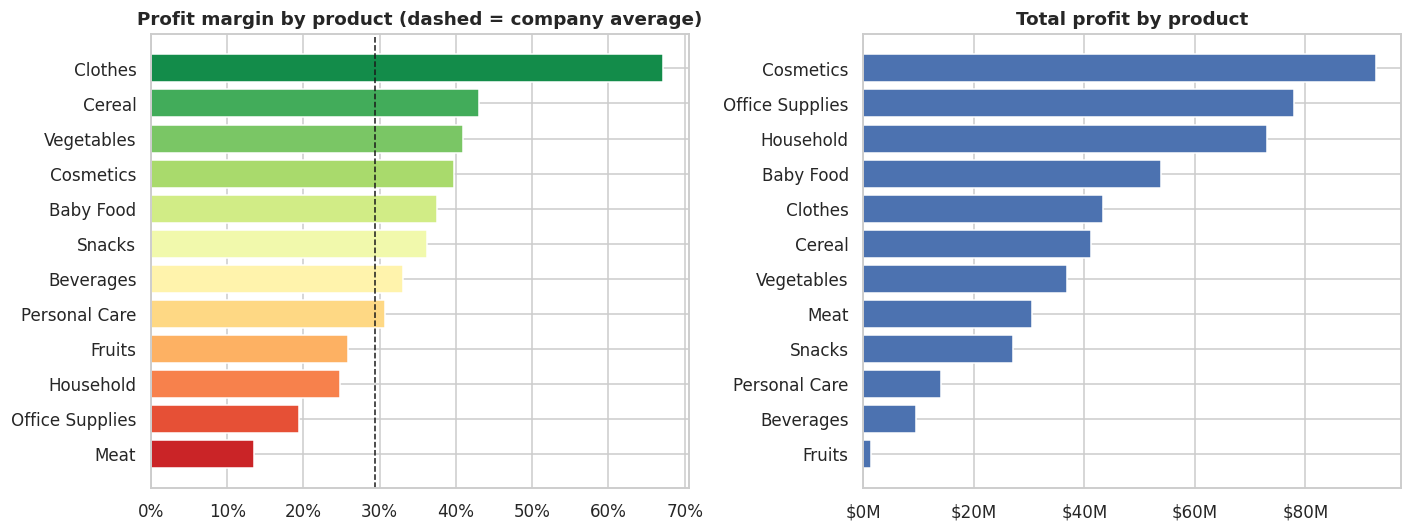

,Revenue,Profit,Units,Orders,Margin
Item Type,,,,,
Cosmetics,"$233,154,825","$92,723,306","533,291",114,39.8%
Office Supplies,"$402,213,996","$77,977,176","617,641",123,19.4%
Household,"$294,205,199","$72,962,467","440,249",97,24.8%
Baby Food,"$143,647,588","$53,940,997","562,706",112,37.6%
Clothes,"$64,626,553","$43,431,314","591,385",105,67.2%
Cereal,"$95,791,404","$41,255,034","465,685",103,43.1%
Vegetables,"$89,746,729","$36,776,003","582,544",114,41.0%
Meat,"$225,026,001","$30,509,107","533,376",111,13.6%
Snacks,"$74,788,613","$27,027,422","490,160",103,36.1%


In [6]:
prod = df.groupby("Item Type").agg(Revenue=("Total Revenue","sum"), Profit=("Total Profit","sum"),
                                   Units=("Units Sold","sum"), Orders=("Order ID","count"))
prod["Margin"] = prod.Profit / prod.Revenue
prod = prod.sort_values("Profit", ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
order = prod.sort_values("Margin").index
ax[0].barh(order, prod.loc[order, "Margin"], color=sns.color_palette("RdYlGn", 12))
ax[0].xaxis.set_major_formatter(P); ax[0].axvline(prof/rev, color="k", ls="--", lw=1)
ax[0].set_title("Profit margin by product (dashed = company average)")
o2 = prod.sort_values("Profit").index
ax[1].barh(o2, prod.loc[o2, "Profit"], color="#4C72B0")
ax[1].xaxis.set_major_formatter(M); ax[1].set_title("Total profit by product")
plt.tight_layout(); plt.show()
prod.style.format({"Revenue":"${:,.0f}","Profit":"${:,.0f}","Units":"{:,.0f}","Margin":"{:.1%}"})

In [7]:
ch = df.groupby("Sales Channel").agg(Revenue=("Total Revenue","sum"), Profit=("Total Profit","sum"), Orders=("Order ID","count"))
ch["Margin"] = ch.Profit / ch.Revenue
display(ch.style.format({"Revenue":"${:,.0f}","Profit":"${:,.0f}","Margin":"{:.1%}"}))

ctry = df.groupby("Country").agg(Revenue=("Total Revenue","sum"), Profit=("Total Profit","sum"))
ctry["Margin"] = ctry.Profit / ctry.Revenue
display(ctry.sort_values("Revenue", ascending=False).head(5).style.format({"Revenue":"${:,.0f}","Profit":"${:,.0f}","Margin":"{:.1%}"}))
print("Revenue spread across 48 countries; top-5 share:", f"{ctry.Revenue.nlargest(5).sum()/ctry.Revenue.sum():.1%}")

,Revenue,Profit,Orders,Margin
Sales Channel,,,,
Offline,"$873,253,614","$253,708,108",667,29.1%
Online,"$830,368,784","$247,967,940",663,29.9%


,Revenue,Profit,Margin
Country,,,
Kosovo,"$53,833,143","$14,409,145",26.8%
Czech Republic,"$53,543,932","$13,635,594",25.5%
Ukraine,"$53,252,318","$14,804,926",27.8%
Bosnia and Herzegovina,"$50,117,508","$13,257,603",26.5%
Macedonia,"$49,222,085","$13,684,100",27.8%


Revenue spread across 48 countries; top-5 share: 15.3%


**Story:** Overall margin is about **29%**, but the product range is very uneven. **Clothes** has the highest margin by far, while **Meat** and **Office Supplies** earn the least per dollar of revenue. Online and offline perform almost identically, and revenue is spread thinly across 48 countries, so no single market dominates.

## 5. Best-selling products

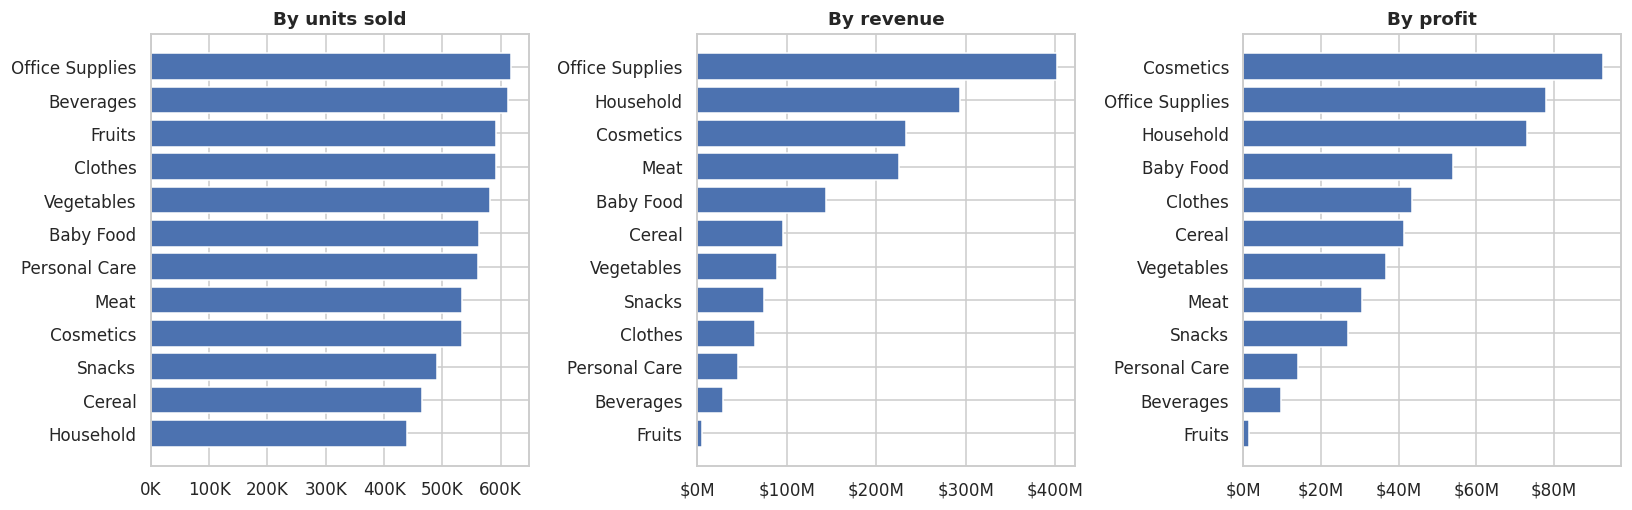

,Units rank,Revenue rank,Profit rank
Item Type,,,
Cosmetics,9,3,1
Office Supplies,1,1,2
Household,12,2,3
Baby Food,6,5,4
Clothes,4,9,5
Cereal,11,6,6
Vegetables,5,7,7
Meat,8,4,8
Snacks,10,8,9


In [8]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.8), sharey=False)
for a, (col, title, fmt) in zip(ax, [("Units","By units sold",None),("Revenue","By revenue",M),("Profit","By profit",M)]):
    s = prod[col].sort_values()
    a.barh(s.index, s.values, color="#4C72B0"); a.set_title(title)
    if fmt: a.xaxis.set_major_formatter(fmt)
    else: a.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f"{x/1e3:,.0f}K"))
plt.tight_layout(); plt.show()

rank = pd.DataFrame({"Units rank": prod.Units.rank(ascending=False).astype(int),
                     "Revenue rank": prod.Revenue.rank(ascending=False).astype(int),
                     "Profit rank": prod.Profit.rank(ascending=False).astype(int)}).sort_values("Profit rank")
rank

**Story:** "Best seller" depends on the measure. **Volume is almost flat across products** (each sells roughly 440K-620K units), so units alone don't separate winners. Revenue and profit do:
- **Office Supplies** leads by units and is a top-3 profit earner, but at a thin ~19% margin.
- **Cosmetics** and **Household** are big revenue/profit drivers.
- **Clothes** punches far above its revenue rank in profit because of its ~67% margin.
- **Fruits** sells a similar volume to the leaders but contributes almost nothing, because its unit price is only $9.33.

## 6. Seasonality

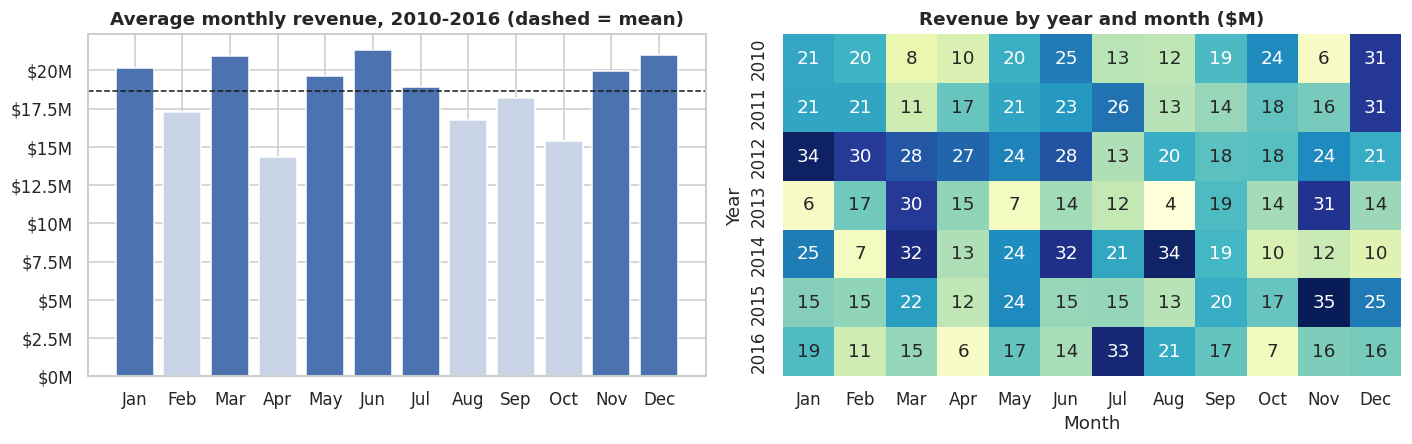

Quarter
1    26.1%
2    24.7%
3    24.1%
4    25.2%


In [9]:
full_years = df[df.Year <= 2016]     # exclude partial 2017 so no month is over-represented
mon = full_years.groupby("Month").agg(Revenue=("Total Revenue","sum"), Profit=("Total Profit","sum"),
                                      Units=("Units Sold","sum"), Orders=("Order ID","count"))
mon["Avg revenue / year"] = mon.Revenue / 7
mon["Margin"] = mon.Profit / mon.Revenue
names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
avg = mon["Avg revenue / year"]
ax[0].bar(names, avg, color=np.where(avg > avg.mean(), "#4C72B0", "#C9D3E6"))
ax[0].axhline(avg.mean(), color="k", ls="--", lw=1); ax[0].yaxis.set_major_formatter(M)
ax[0].set_title("Average monthly revenue, 2010-2016 (dashed = mean)")
heat = full_years.pivot_table(index="Year", columns="Month", values="Total Revenue", aggfunc="sum") / 1e6
sns.heatmap(heat, cmap="YlGnBu", annot=True, fmt=".0f", cbar=False, ax=ax[1], xticklabels=names)
ax[1].set_title("Revenue by year and month ($M)")
plt.tight_layout(); plt.show()

q = full_years.groupby("Quarter")["Total Revenue"].sum(); print((q/q.sum()).map("{:.1%}".format).to_string())

**Story:** Seasonality here is **weak**. Quarterly shares sit between 24% and 26%, and the best month beats the worst by only about 1.5x. The softest months are **April, October and August** (April is lowest at ~$14M a year on average); **June, December, March and January** run strongest. The heatmap shows individual months swing a lot from year to year (a few large orders can move a month), so use this as a rough planning guide, not a forecast. 2017 is excluded so its Jan-Jul data doesn't inflate the first half of the year.

## 7. Promotional campaign impact

In [10]:
print("Columns:", list(df.columns))
print("Any promo/discount column?", any(k in c.lower() for c in df.columns for k in ["promo","discount","campaign","coupon","offer"]))
print("Products with more than one unit price over 7.5 years:", int((df.groupby("Item Type")["Unit Price"].nunique() > 1).sum()))

Columns: ['Region', 'Country', 'Item Type', 'Sales Channel', 'Order Priority', 'Order Date', 'Order ID', 'Ship Date', 'Units Sold', 'Unit Price', 'Unit Cost', 'Total Revenue', 'Total Cost', 'Total Profit', 'Year', 'Month', 'Quarter', 'Ship Days']
Any promo/discount column? False
Products with more than one unit price over 7.5 years: 0


**This dataset cannot measure promotional impact directly.**
- There is no promotion, discount, or campaign field.
- Every product sells at a single constant price and cost, so there is no price cut to isolate.

Presenting a "promo uplift number" would be invented. What I *can* do is test whether there are **unusual demand spikes** that a campaign could plausibly explain, and recommend what data to collect.

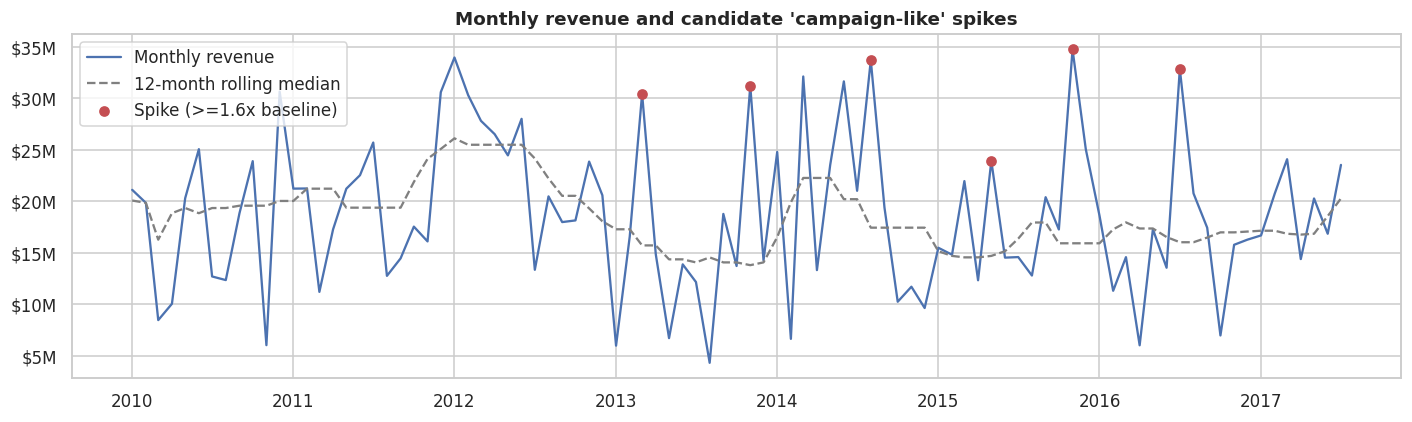

,Date,Revenue,Orders,Baseline,Ratio
46,Nov 2013,"$31,202,910",19,"$13,806,152",2.26x
70,Nov 2015,"$34,741,355",17,"$15,929,561",2.18x
78,Jul 2016,"$32,853,572",16,"$16,031,847",2.05x
38,Mar 2013,"$30,434,095",20,"$15,723,567",1.94x
55,Aug 2014,"$33,697,626",20,"$17,444,682",1.93x
64,May 2015,"$23,927,191",15,"$14,705,404",1.63x


In [11]:
monthly = df.groupby(["Year","Month"]).agg(Revenue=("Total Revenue","sum"), Orders=("Order ID","count")).reset_index()
monthly = monthly[~((monthly.Year == 2017) & (monthly.Month > 7))]
monthly["Date"] = pd.to_datetime(dict(year=monthly.Year, month=monthly.Month, day=1))
monthly["Baseline"] = monthly.Revenue.rolling(12, center=True, min_periods=6).median()
monthly["Ratio"] = monthly.Revenue / monthly.Baseline
spikes = monthly[monthly.Ratio >= 1.6].sort_values("Ratio", ascending=False)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(monthly.Date, monthly.Revenue, color="#4C72B0", label="Monthly revenue")
ax.plot(monthly.Date, monthly.Baseline, color="grey", ls="--", label="12-month rolling median")
ax.scatter(spikes.Date, spikes.Revenue, color="#C44E52", zorder=3, label="Spike (>=1.6x baseline)")
ax.yaxis.set_major_formatter(M); ax.set_title("Monthly revenue and candidate 'campaign-like' spikes"); ax.legend()
plt.tight_layout(); plt.show()
spikes[["Date","Revenue","Orders","Baseline","Ratio"]].assign(Date=lambda d: d.Date.dt.strftime("%b %Y")).style.format(
    {"Revenue":"${:,.0f}","Baseline":"${:,.0f}","Ratio":"{:.2f}x"})

In [12]:
if len(spikes):
    sp = spikes.head(5)
    print("Do spikes come from more orders (traffic/promo-like) or bigger orders?")
    base_orders = monthly.Orders.median()
    for _, r in sp.iterrows():
        print(f"{r.Date:%b %Y}: {int(r.Orders)} orders vs median {base_orders:.0f}; avg order ${r.Revenue/r.Orders/1e6:.2f}M vs overall ${rev/len(df)/1e6:.2f}M")

Do spikes come from more orders (traffic/promo-like) or bigger orders?
Nov 2013: 19 orders vs median 15; avg order $1.64M vs overall $1.28M
Nov 2015: 17 orders vs median 15; avg order $2.04M vs overall $1.28M
Jul 2016: 16 orders vs median 15; avg order $2.05M vs overall $1.28M
Mar 2013: 20 orders vs median 15; avg order $1.52M vs overall $1.28M
Aug 2014: 20 orders vs median 15; avg order $1.68M vs overall $1.28M


**Interpretation:** The spike months combine slightly more orders than usual with larger-than-average order sizes, which is consistent with a campaign but equally consistent with random clustering of big B2B-style orders. Nothing here is strong enough to credit to a promotion. Treat these months as hypotheses to check against the real marketing calendar.

**To measure promo impact properly, collect:** campaign start/end dates, discount % per order, promo code or flag, and ad spend. Then compare promo vs non-promo periods on units, revenue, and **margin after discount** (a promo that lifts volume but cuts margin can still lose money).

## 8. Fulfilment (supporting view)

In [13]:
pri = df.groupby("Order Priority").agg(Orders=("Order ID","count"), AvgShipDays=("Ship Days","mean"), Revenue=("Total Revenue","sum"))
pri.style.format({"AvgShipDays":"{:.1f}","Revenue":"${:,.0f}"})

,Orders,AvgShipDays,Revenue
Order Priority,,,
C,307,23.7,"$412,253,235"
H,335,24.3,"$436,294,865"
L,334,25.1,"$388,509,487"
M,354,25.8,"$466,564,811"


## 9. Executive summary and recommendations

| Question | Finding |
|---|---|
| **Trend** | Revenue peaked in 2012, then became volatile and fell about 33% by 2016. 2017 is a partial year but is running about 20% ahead of 2016 on a Jan-Jul basis. |
| **Margin** | ~29% overall and stable year to year. Clothes is far above average; Meat and Office Supplies are far below. |
| **Top sellers** | Depends on the lens: volume is flat across products, but Cosmetics, Household, Office Supplies and Clothes drive the profit. |
| **Seasonality** | Weak overall (quarters 24-26%). April, October and August are the softest months; June, December, March and January are strongest. |
| **Promotions** | Not measurable with this data (no promo field, constant prices). |

**Recommendations**
1. **Protect and grow high-margin lines** (Clothes, Cereal, Vegetables, Cosmetics): feature them in the weak months to lift profit, not just revenue.
2. **Fix or reprice low-margin lines.** Meat (~14%) and Office Supplies (~19%) tie up a lot of revenue for little profit. Review supplier cost or raise price.
3. **Drop or bundle Fruits.** Similar volume to leaders, almost no profit.
4. **Test promotions in the soft months** (April, October, August) and track them properly this time.
5. **Start capturing promo data** so the next analysis can answer the campaign question with evidence.